# Advanced Fourier Methods

## 1. Introduction to the Spectral Perspective

In the analysis of time-series data—whether it's an audio signal, stock market fluctuations, or gravitational waves—viewing data purely as a function of time $x(t)$ often obscures underlying periodicities and systemic behaviors.

The Fourier transform is the mathematical bridge that takes us from the time domain to the frequency (or spectral) domain. Lets discuss how to apply these transforms, how they interact through convolution and correlation, and how we handle the messy realities of finite data through windowing and filtering.



## 2. The Fourier Transform: Foundations and Derivations

### 2.1 From Fourier Series to the Fourier Transform

We begin with a periodic signal $x_T(t)$ with period $T$. The Fourier Series states that this signal can be represented as an infinite sum of complex exponentials:

$$x_T(t) = \sum_{n=-\infty}^{\infty} c_n e^{i \omega_n t}$$

where the fundamental frequency is $\omega_0 = \frac{2\pi}{T}$, and harmonics are $\omega_n = n\omega_0$. The coefficients $c_n$ are derived by projecting $x_T(t)$ onto the orthogonal basis functions $e^{-i \omega_n t}$:

$$c_n = \frac{1}{T} \int_{-T/2}^{T/2} x_T(t) e^{-i \omega_n t} dt$$

**Derivation of the Fourier Transform:**
To analyze aperiodic (non-periodic) signals, we let the period $T \to \infty$. As $T \to \infty$, the fundamental frequency $\omega_0 = \Delta\omega \to 0$, and the discrete spectrum $\omega_n$ becomes a continuous variable $\omega$.

Substitute $c_n$ into the series:

$$x(t) = \lim_{T \to \infty} \sum_{n=-\infty}^{\infty} \left[ \frac{1}{T} \int_{-T/2}^{T/2} x(\tau) e^{-i n \omega_0 \tau} d\tau \right] e^{i n \omega_0 t}$$

Since $\Delta\omega = \frac{2\pi}{T}$, we have $\frac{1}{T} = \frac{\Delta\omega}{2\pi}$. Substituting this:

$$x(t) = \lim_{\Delta\omega \to 0} \frac{1}{2\pi} \sum_{n=-\infty}^{\infty} \left[ \int_{-\infty}^{\infty} x(\tau) e^{-i \omega_n \tau} d\tau \right] e^{i \omega_n t} \Delta\omega$$

By the definition of the Riemann integral, the infinite sum becomes an integral over $\omega$ as $\Delta\omega \to 0$:

$$x(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} \left[ \int_{-\infty}^{\infty} x(\tau) e^{-i \omega \tau} d\tau \right] e^{i \omega t} d\omega$$

The inner integral is defined as the **Continuous Fourier Transform (CFT)**, $X(\omega)$, and the outer integral is the **Inverse Fourier Transform (ICFT)**.

**Definitions**:


$$X(\omega) = \mathcal{F}\{x(t)\} = \int_{-\infty}^{\infty} x(t) e^{-i \omega t} dt$$

$$x(t) = \mathcal{F}^{-1}\{X(\omega)\} = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega) e^{i \omega t} d\omega$$

Note on when to use: Use the Continuous Fourier Transform for analytical, continuous-time mathematical models. In computational data analysis, we adapt this into the Discrete Fourier Transform (DFT), computed via the Fast Fourier Transform (FFT) algorithm.



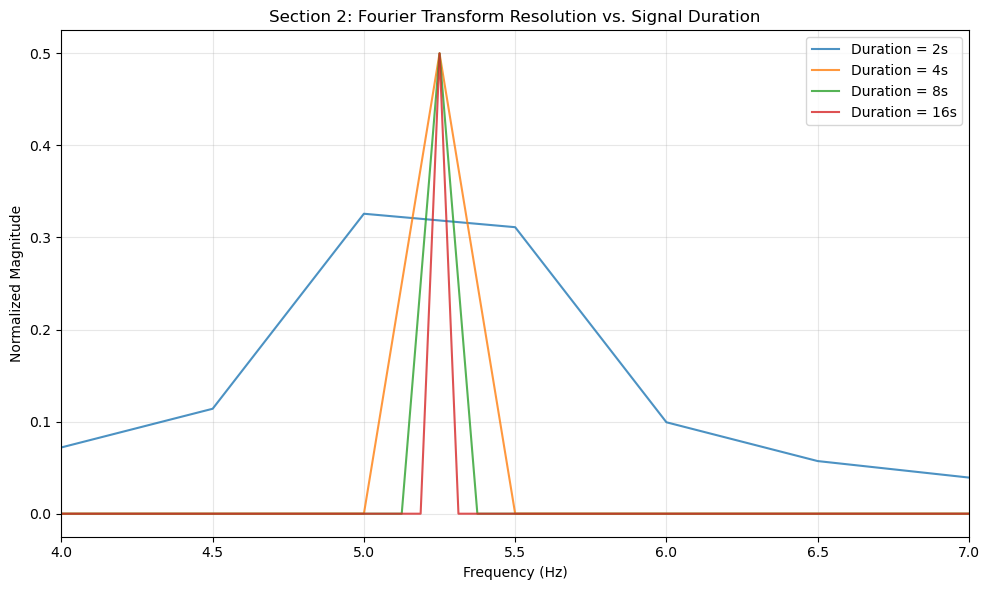

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def section2_fourier_resolution():
    """
    Section 2: Fourier Transform of a periodic signal for different durations.
    Demonstrates how frequency resolution improves (spectral peaks narrow) 
    as the time-domain signal duration increases.
    """
    fs = 100  # Sampling frequency
    f0 = 5.25 # Non-integer frequency to clearly show leakage and resolution
    durations = [2, 4, 8, 16] # in seconds
    
    plt.figure(figsize=(10, 6))
    
    for T in durations:
        t = np.arange(0, T, 1/fs)
        x = np.sin(2 * np.pi * f0 * t)
        
        # Compute FFT
        X = np.fft.fft(x)
        freqs = np.fft.fftfreq(len(x), 1/fs)
        
        # Keep only positive frequencies
        mask = freqs >= 0
        
        # Normalize magnitude by length of signal
        magnitude = np.abs(X[mask]) / len(x)
        
        plt.plot(freqs[mask], magnitude, label=f'Duration = {T}s', linewidth=1.5, alpha=0.8)

    plt.xlim(4, 7) # Zoom in around the fundamental frequency
    plt.title('Section 2: Fourier Transform Resolution vs. Signal Duration')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Normalized Magnitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

section2_fourier_resolution()

## 3. Spectral Transform and Energy Representation

When dealing with stochastic processes or noise, the raw Fourier transform $X(\omega)$ often isn't mathematically well-behaved (it may not converge). When we say the raw Fourier transform "may not converge," we are talking about a strict mathematical requirement of the Fourier integral itself.

The continuous Fourier Transform calculates an integral of a signal from negative infinity to positive infinity ($\int_{-\infty}^{\infty} x(t) e^{-i\omega t} dt$). For this integral to settle on a finite, well-defined number (i.e., to converge), the signal must satisfy Dirichlet's condition of absolute integrability. In practical terms, this means the signal must have **finite total energy**—it has to eventually decay to zero at its ends.

However, many real-world signals don't behave this way:

- **Stochastic processes/Noise**: Background thermal noise, stock market fluctuations, or static don't die out; they keep going indefinitely.

- **Persistent signals**: A continuous sine wave that plays forever.

Because these signals go on forever, they possess **infinite total energy**. If you try to feed an infinite-energy signal into the raw Fourier transform integral, the area under the curve never settles; the integral "blows up" to infinity, meaning it fails to converge.

Since we cannot use the standard Fourier Transform on infinite-energy signals, we have to change our perspective from *Energy* to *Power* (which is energy per unit of time). The **Power Spectral Density** (PSD) effectively averages out the infinite time aspect, giving us a stable, convergent, and well-behaved mathematical view of how the signal's power is distributed across frequencies. 

### 3.1 Parseval's and Plancherel's Theorem

To understand spectral power, we must prove that energy is conserved between domains. Let's derive Parseval's Theorem for finite-energy signals.

Total Energy $E = \int_{-\infty}^{\infty} |x(t)|^2 dt = \int_{-\infty}^{\infty} x(t)x^*(t) dt$.

Using the inverse Fourier transform for $x(t)$:


$$E = \int_{-\infty}^{\infty} \left( \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega) e^{i \omega t} d\omega \right) x^*(t) dt$$

Swap the order of integration (allowed by Fubini's theorem for well-behaved functions):


$$E = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega) \left[ \int_{-\infty}^{\infty} x^*(t) e^{i \omega t} dt \right] d\omega$$

Notice that the inner integral is exactly the complex conjugate of the Fourier Transform:


$$\int_{-\infty}^{\infty} x^*(t) e^{i \omega t} dt = \left( \int_{-\infty}^{\infty} x(t) e^{-i \omega t} dt \right)^* = X^*(\omega)$$

Therefore:


$$E = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega)X^*(\omega) d\omega = \frac{1}{2\pi} \int_{-\infty}^{\infty} |X(\omega)|^2 d\omega$$

The quantity $|X(\omega)|^2$ is the **Energy Spectral Density**. For continuous data analysis (like vibration analysis or acoustics), we look at $|X(\omega)|^2 / T$ (**Power Spectral Density**) to find dominant frequency bands.

When to use: Use the Spectral Transform (PSD) when identifying dominant cycles in noisy data, estimating the noise floor, or checking for resonance frequencies. It strips away phase information, focusing purely on magnitude/power.

--------------------------------------------------
Section 3: Parseval's Theorem Verification
Energy (Time Domain):      4687.127243
Energy (Frequency Domain): 4687.127243
Difference:                9.09e-13
--------------------------------------------------


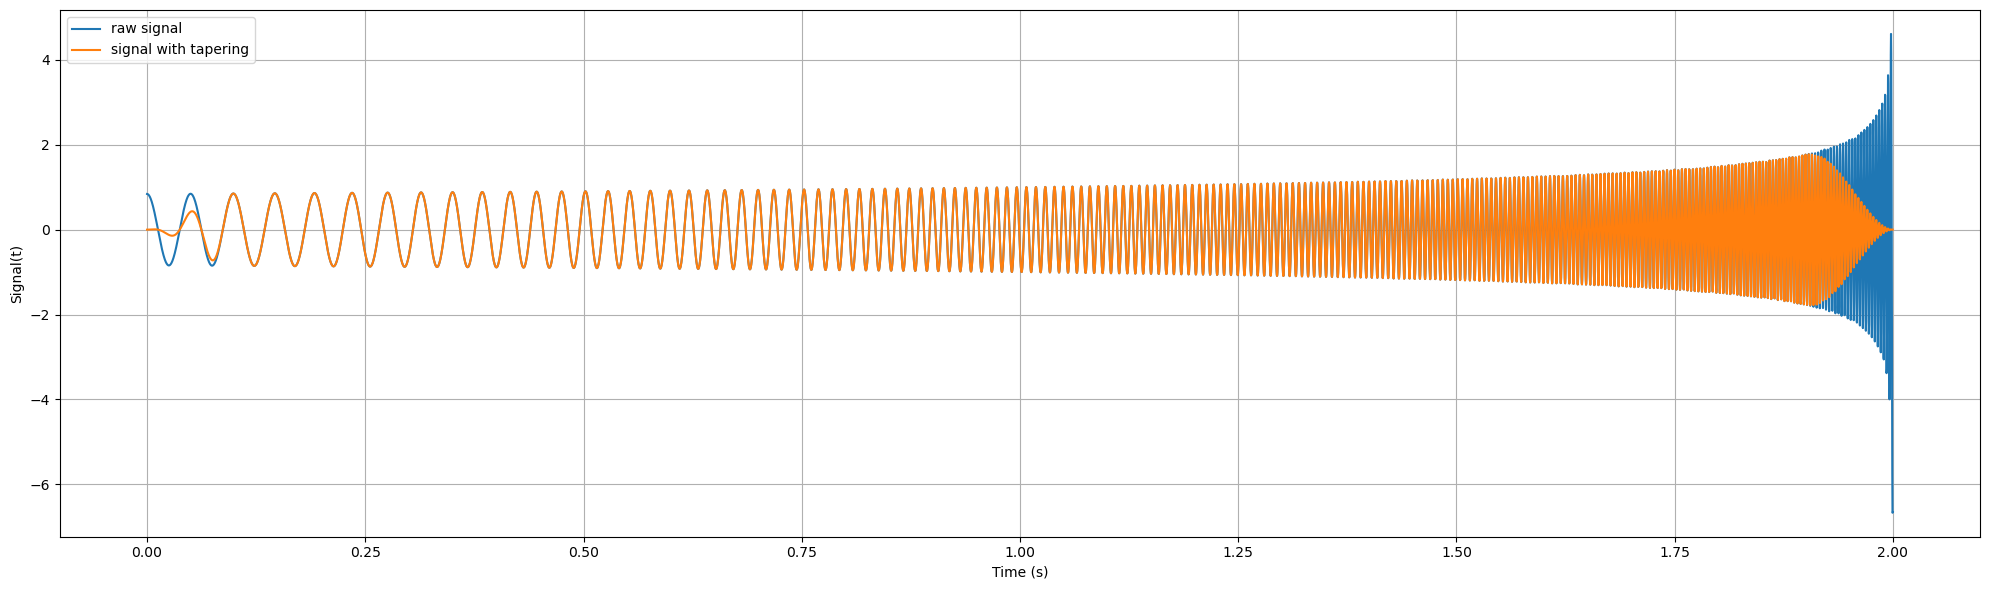

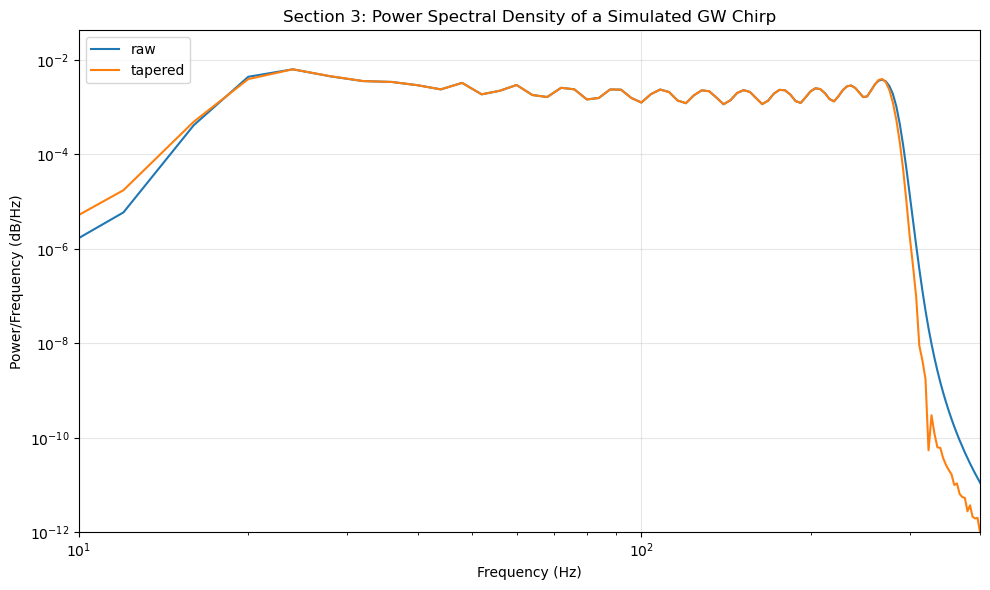

In [2]:
def section3_gw_psd_parseval():
    """
    Section 3: PSD of a post-Newtonian gravitational wave (chirp) and 
    verification of Parseval's Theorem.
    """
    from scipy import signal
    fs = 4096
    t = np.arange(0, 2, 1/fs)
    
    # Simulate a binary inspiral GW signal using a frequency chirp 
    # (starts at 20Hz, sweeps up to 300Hz quadratically)
    h_t = signal.chirp(t, f0=20, f1=300, t1=2, method='quadratic')

    ampl = ((len(h_t) - np.arange(len(h_t))) / fs)**(-0.25)
    h_t *= ampl
    
    # Apply a window to taper the ends (common in GW data conditioning)
    h_t_untapered = h_t.copy()
    h_t *= signal.windows.tukey((len(h_t)), alpha=0.1)
    
    # --- Parseval's Theorem Verification ---
    # Energy in Time Domain: Sum of |x(t)|^2
    energy_time = np.sum(np.abs(h_t)**2)
    
    # Energy in Frequency Domain: Sum of |X(f)|^2 / N
    H_f_untapered = np.fft.fft(h_t_untapered)
    H_f = np.fft.fft(h_t)
    energy_freq = np.sum(np.abs(H_f)**2) / len(h_t)
    
    print("-" * 50)
    print("Section 3: Parseval's Theorem Verification")
    print(f"Energy (Time Domain):      {energy_time:.6f}")
    print(f"Energy (Frequency Domain): {energy_freq:.6f}")
    print(f"Difference:                {abs(energy_time - energy_freq):.2e}")
    print("-" * 50)

    # --- Signal timeseries ---
    plt.figure(figsize=(20, 6))
    plt.plot(t, h_t_untapered, label="raw signal")
    plt.plot(t, h_t, label="signal with tapering")
    plt.xlabel('Time (s)')
    plt.ylabel('Signal(t)')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    # --- Power Spectral Density ---
    # Compute PSD using Welch's method to smooth the spectrum
    plt.figure(figsize=(10, 6))
    freqs, Pxx = signal.welch(h_t_untapered, fs, nperseg=1024, window='hann')
    plt.loglog(freqs, Pxx, label='raw')
    freqs, Pxx = signal.welch(h_t, fs, nperseg=1024, window='hann')
    plt.loglog(freqs, Pxx, label='tapered')

    plt.title('Section 3: Power Spectral Density of a Simulated GW Chirp')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power/Frequency (dB/Hz)')
    plt.xlim(10, 400)
    plt.ylim(ymin=1e-12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

section3_gw_psd_parseval()


## 4. The Convolution Theorem

Convolution is arguably the most important mathematical operation in signal processing. The convolution of two signals $f(t)$ and $g(t)$ is defined as:

$$(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) g(t - \tau) d\tau$$

Physically, if $f(t)$ is an input signal and $g(t)$ is the impulse response of a linear time-invariant (LTI) system, then $(f * g)(t)$ is the output.

### 4.1 Derivation of the Convolution Theorem

The theorem states that convolution in the time domain equals multiplication in the frequency domain. Let's prove $\mathcal{F}\{(f * g)(t)\} = F(\omega)G(\omega)$.

$$\mathcal{F}\{f * g\} = \int_{-\infty}^{\infty} \left[ \int_{-\infty}^{\infty} f(\tau) g(t - \tau) d\tau \right] e^{-i \omega t} dt$$

Swap the order of integration:


$$\mathcal{F}\{f * g\} = \int_{-\infty}^{\infty} f(\tau) \left[ \int_{-\infty}^{\infty} g(t - \tau) e^{-i \omega t} dt \right] d\tau$$

Let $u = t - \tau$. Then $dt = du$, and $t = u + \tau$. Substitute into the inner integral:


$$\int_{-\infty}^{\infty} g(u) e^{-i \omega (u + \tau)} du = e^{-i \omega \tau} \int_{-\infty}^{\infty} g(u) e^{-i \omega u} du = e^{-i \omega \tau} G(\omega)$$

Substitute this back into the outer integral:


$$\mathcal{F}\{f * g\} = \int_{-\infty}^{\infty} f(\tau) \left[ e^{-i \omega \tau} G(\omega) \right] d\tau = G(\omega) \int_{-\infty}^{\infty} f(\tau) e^{-i \omega \tau} d\tau$$

$$\mathcal{F}\{f * g\} = F(\omega)G(\omega)$$

**When to use**: This theorem is the bedrock of fast computation. Computing a convolution directly in time takes $O(N^2)$ operations. By transforming the data via FFT to the frequency domain, multiplying $F(\omega)G(\omega)$, and applying the inverse FFT, we reduce the computational complexity to $O(N \log N)$. This is used universally in digital filtering, reverb effects, and solving differential equations.



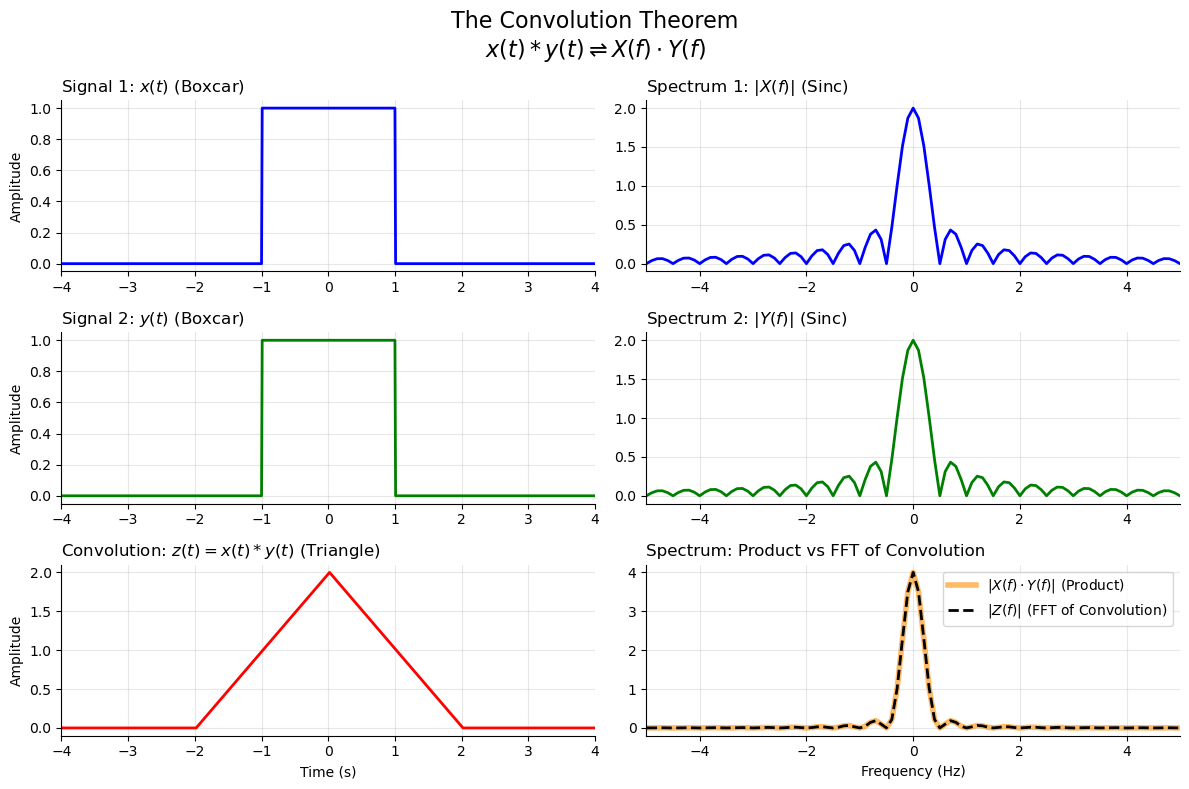

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def plot_convolution_theorem():
    fs = 100
    t = np.arange(-5, 5, 1/fs)
    
    # 1. Define two signals in time domain (two rectangular pulses)
    pulse_width = 2
    x = np.where(np.abs(t) <= pulse_width/2, 1.0, 0.0)
    y = np.where(np.abs(t) <= pulse_width/2, 1.0, 0.0)
    
    # Time-domain convolution (z_time = x * y)
    z_time = np.convolve(x, y, mode='same') / fs  # normalize by sampling rate
    
    # 2. Compute Frequency Domain representations
    freqs = np.fft.fftshift(np.fft.fftfreq(len(t), 1/fs))
    
    X = np.fft.fftshift(np.fft.fft(x)) / fs
    Y = np.fft.fftshift(np.fft.fft(y)) / fs
    
    # Frequency-domain multiplication (Z_freq = X * Y)
    Z_freq = X * Y
    
    # Check FFT of the convolved signal
    Z_from_time = np.fft.fftshift(np.fft.fft(z_time)) / fs

    fig, axs = plt.subplots(3, 2, figsize=(12, 8))
    fig.suptitle('The Convolution Theorem\n$x(t) * y(t) \\rightleftharpoons X(f) \\cdot Y(f)$', fontsize=16)
    
    # Make styling prettier
    for ax in axs.flat:
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Top Left: Signal 1 (Time)
    axs[0, 0].plot(t, x, 'b', lw=2)
    axs[0, 0].set_title('Signal 1: $x(t)$ (Boxcar)', loc='left')
    axs[0, 0].set_ylabel('Amplitude')
    axs[0, 0].set_xlim(-4, 4)

    # Top Right: Signal 1 (Freq)
    axs[0, 1].plot(freqs, np.abs(X), 'b', lw=2)
    axs[0, 1].set_title('Spectrum 1: $|X(f)|$ (Sinc)', loc='left')
    axs[0, 1].set_xlim(-5, 5)

    # Middle Left: Signal 2 (Time)
    axs[1, 0].plot(t, y, 'g', lw=2)
    axs[1, 0].set_title('Signal 2: $y(t)$ (Boxcar)', loc='left')
    axs[1, 0].set_ylabel('Amplitude')
    axs[1, 0].set_xlim(-4, 4)

    # Middle Right: Signal 2 (Freq)
    axs[1, 1].plot(freqs, np.abs(Y), 'g', lw=2)
    axs[1, 1].set_title('Spectrum 2: $|Y(f)|$ (Sinc)', loc='left')
    axs[1, 1].set_xlim(-5, 5)

    # Bottom Left: Convolution (Time)
    axs[2, 0].plot(t, z_time, 'r', lw=2)
    axs[2, 0].set_title('Convolution: $z(t) = x(t) * y(t)$ (Triangle)', loc='left')
    axs[2, 0].set_xlabel('Time (s)')
    axs[2, 0].set_ylabel('Amplitude')
    axs[2, 0].set_xlim(-4, 4)

    # Bottom Right: Spectrum (Freq)
    axs[2, 1].plot(freqs, np.abs(Z_freq), 'darkorange', lw=4, alpha=0.6, label='$|X(f) \\cdot Y(f)|$ (Product)')
    axs[2, 1].plot(freqs, np.abs(Z_from_time), 'k--', lw=2, label='$|Z(f)|$ (FFT of Convolution)')
    axs[2, 1].set_title('Spectrum: Product vs FFT of Convolution', loc='left')
    axs[2, 1].set_xlabel('Frequency (Hz)')
    axs[2, 1].set_xlim(-5, 5)
    axs[2, 1].legend()

    plt.tight_layout()
    plt.savefig('convolution_theorem.png')

plot_convolution_theorem()

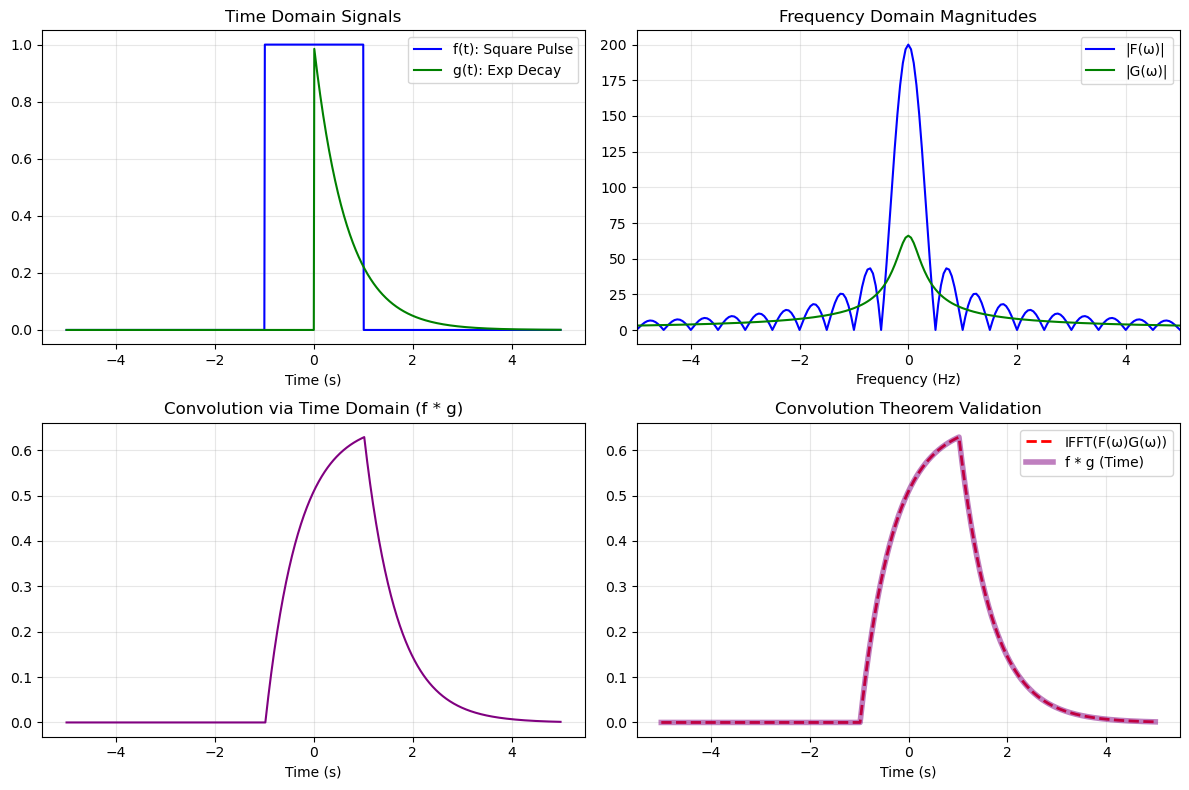

In [4]:
def section4_convolution():
    """
    Section 4: Convolution of a square pulse and an exponential decay.
    Demonstrates the Convolution Theorem by performing convolution in 
    both the time and frequency domains.
    """
    fs = 100
    t = np.arange(-5, 5, 1/fs)
    dt = 1/fs
    N = len(t)
    
    # Signal 1: Square pulse (input signal)
    f = np.where((t > -1) & (t < 1), 1.0, 0.0)
    
    # Signal 2: Exponential decay (system impulse response)
    g = np.where(t >= 0, np.exp(-1.5 * t), 0.0)
    
    # --- Method 1: Time-Domain Convolution ---
    # Multiply by dt to approximate continuous integral correctly
    conv_time = np.convolve(f, g, mode='same') * dt
    
    # --- Method 2: Frequency-Domain Convolution (The Theorem) ---
    # Pad to N + N - 1 to avoid circular aliasing during FFT convolution
    K = 2 * N - 1
    F_omega = np.fft.fft(f, n=K)
    G_omega = np.fft.fft(g, n=K)
    
    # Multiply in frequency domain: Y(ω) = F(ω) * G(ω)
    Y_omega = F_omega * G_omega
    
    # Inverse FFT to get back to time domain
    conv_freq_full = np.fft.ifft(Y_omega).real * dt
    
    # Extract the 'same' window to match the time-domain array size
    start = (K - N) // 2
    conv_freq = conv_freq_full[start : start + N]
    
    # --- Visualization ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Top-Left: Original Signals in Time
    axes[0, 0].plot(t, f, label='f(t): Square Pulse', color='blue')
    axes[0, 0].plot(t, g, label='g(t): Exp Decay', color='green')
    axes[0, 0].set_title('Time Domain Signals')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Top-Right: Frequency Domain Magnitudes
    freqs = np.fft.fftfreq(K, dt)
    freqs_shifted = np.fft.fftshift(freqs)
    F_shifted = np.fft.fftshift(np.abs(F_omega))
    G_shifted = np.fft.fftshift(np.abs(G_omega))
    
    axes[0, 1].plot(freqs_shifted, F_shifted, label='|F(ω)|', color='blue')
    axes[0, 1].plot(freqs_shifted, G_shifted, label='|G(ω)|', color='green')
    axes[0, 1].set_title('Frequency Domain Magnitudes')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_xlim(-5, 5) # Zoom in to see the main lobes
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Bottom-Left: Time-domain convolution output
    axes[1, 0].plot(t, conv_time, color='purple')
    axes[1, 0].set_title('Convolution via Time Domain (f * g)')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Bottom-Right: Frequency-domain convolution output (IFFT overlay)
    axes[1, 1].plot(t, conv_freq, color='red', linestyle='--', linewidth=2, label='IFFT(F(ω)G(ω))')
    axes[1, 1].plot(t, conv_time, color='purple', alpha=0.5, linewidth=4, label='f * g (Time)')
    axes[1, 1].set_title('Convolution Theorem Validation')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

section4_convolution()

## 5. The Correlation Theorem and Wiener-Khinchin

Cross-correlation measures the similarity between two signals as a function of the displacement of one relative to the other.

$$(f \star g)(t) = \int_{-\infty}^{\infty} f^*(\tau) g(t + \tau) d\tau$$

**Derivation of the Correlation Theorem**

Let's find $\mathcal{F}\{(f \star g)(t)\}$.

$$\mathcal{F}\{f \star g\} = \int_{-\infty}^{\infty} \left[ \int_{-\infty}^{\infty} f^*(\tau) g(t + \tau) d\tau \right] e^{-i \omega t} dt$$

Swap integrals:


$$= \int_{-\infty}^{\infty} f^*(\tau) \left[ \int_{-\infty}^{\infty} g(t + \tau) e^{-i \omega t} dt \right] d\tau$$

Let $u = t + \tau \implies t = u - \tau$.


$$= \int_{-\infty}^{\infty} f^*(\tau) \left[ \int_{-\infty}^{\infty} g(u) e^{-i \omega (u - \tau)} du \right] d\tau$$

$$= \int_{-\infty}^{\infty} f^*(\tau) e^{i \omega \tau} \left[ \int_{-\infty}^{\infty} g(u) e^{-i \omega u} du \right] d\tau$$

$$= G(\omega) \int_{-\infty}^{\infty} f^*(\tau) e^{-i (-\omega) \tau} d\tau$$

Recognize that $\int f^*(\tau) e^{i \omega \tau} d\tau = \left[ \int f(\tau) e^{-i \omega \tau} d\tau \right]^* = F^*(\omega)$. Thus:

$$\mathcal{F}\{f \star g\} = F^*(\omega)G(\omega)$$

**The Wiener-Khinchin Theorem**:
If we compute the autocorrelation of a signal ($f = g$), the theorem yields $\mathcal{F}\{f \star f\} = F^*(\omega)F(\omega) = |F(\omega)|^2$.
This reveals a profound truth: **The Fourier transform of the autocorrelation function is the Power Spectral Density**.

**When to use:** Use Cross-correlation to find time delays (e.g., radar, sonar, GPS signal alignment). Use Autocorrelation via Wiener-Khinchin to robustly estimate spectra in highly stochastic environments, such as predicting turbulent fluid flows or statistical finance models.



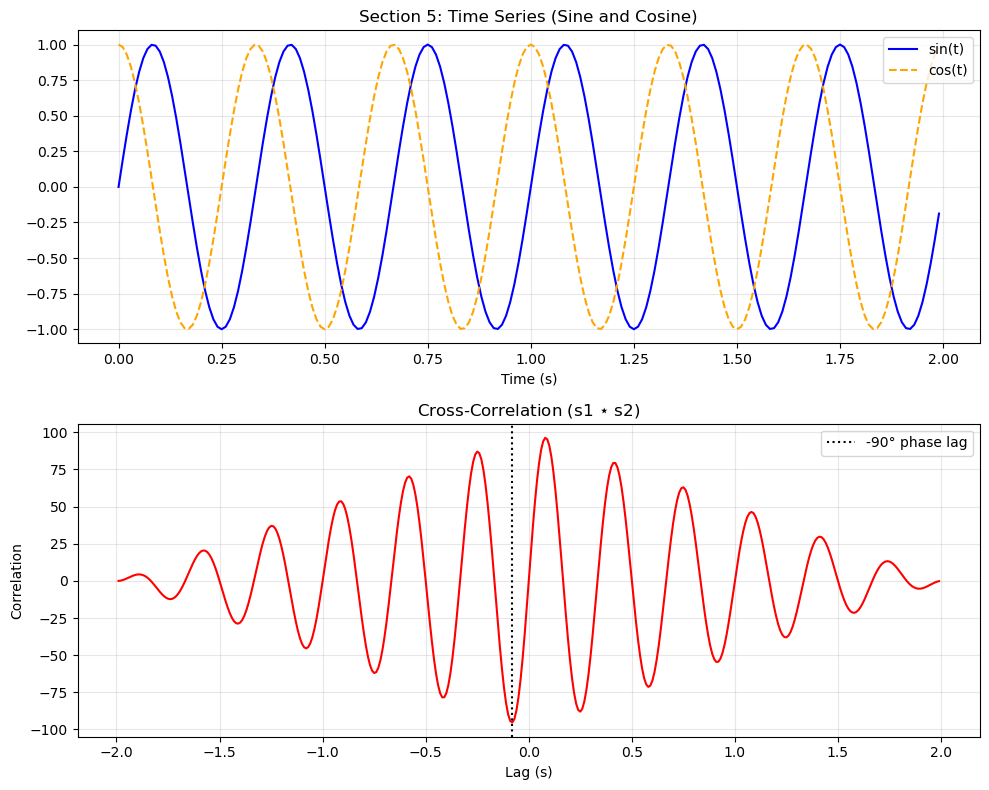

In [5]:
def section5_correlation():
    """
    Section 5: Cross-correlation between Sine and Cosine.
    Shows the time series and the resulting cross-correlation peak.
    """
    fs = 100
    t = np.arange(0, 2, 1/fs)
    freq = 3 # 3 Hz
    
    # Signals
    s1 = np.sin(2 * np.pi * freq * t)
    s2 = np.cos(2 * np.pi * freq * t)
    
    # Cross-correlation
    corr = signal.correlate(s1, s2, mode='full')
    lags = signal.correlation_lags(len(s1), len(s2)) / fs
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    # Plot original signals
    axes[0].plot(t, s1, label='sin(t)', color='blue')
    axes[0].plot(t, s2, label='cos(t)', color='orange', linestyle='--')
    axes[0].set_title('Section 5: Time Series (Sine and Cosine)')
    axes[0].set_xlabel('Time (s)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Plot Cross-correlation
    axes[1].plot(lags, corr, color='red')
    axes[1].set_title('Cross-Correlation (s1 $\star$ s2)')
    axes[1].set_xlabel('Lag (s)')
    axes[1].set_ylabel('Correlation')
    # Add a marker at the expected phase shift (90 degrees = 1/4 cycle)
    phase_shift_lag = 1 / (4 * freq)
    axes[1].axvline(-phase_shift_lag, color='black', linestyle=':', label='-90° phase lag')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

section5_correlation()


## 6. Real-World Data: Finite Time Series & Gibbs Phenomenon

In reality, we never have an infinitely long signal. We have a finite time series of length $T_0$. Mathematically, observing a signal $x(t)$ over a finite window is equivalent to multiplying the infinite signal by a rectangular window $w(t)$:

$$w(t) = \begin{cases} 1 & |t| < T_0/2 \\ 0 & |t| > T_0/2 \end{cases}$$

Observed signal: $y(t) = x(t) w(t)$.
By the convolution theorem (dual form): multiplication in time is convolution in frequency:


$$Y(\omega) = \frac{1}{2\pi} [X * W](\omega)$$

The Fourier transform of the rectangular window $w(t)$ is a Sinc function:


$$W(\omega) = \int_{-T_0/2}^{T_0/2} e^{-i\omega t} dt = \frac{e^{-i\omega T_0/2} - e^{i\omega T_0/2}}{-i\omega} = \frac{2\sin(\omega T_0/2)}{\omega} = T_0 \text{sinc}\left(\frac{\omega T_0}{2\pi}\right)$$

Convolving the true spectrum $X(\omega)$ with a Sinc function causes **Spectral Leakage**—energy from a single frequency "leaks" into adjacent frequencies due to the infinite side-lobes of the Sinc function.

### 6.1 The Gibbs Phenomenon: A Rigorous Look

The Gibbs phenomenon describes the behavior of a Fourier series near jump discontinuities. When attempting to reconstruct a square wave (or a truncated signal) using a finite number of Fourier components, the approximation will exhibit an overshoot near the discontinuity that does not disappear as the number of terms increases.

**Derivation**:
Consider a square wave $f(x)$ on $[-\pi, \pi]$, where $f(x) = -1$ for $x \in (-\pi, 0)$ and $f(x) = 1$ for $x \in (0, \pi)$.
The truncated Fourier series up to $N$ terms is:


$$S_N(x) = \frac{4}{\pi} \sum_{k=1}^N \frac{\sin((2k-1)x)}{2k-1}$$

To understand how this discrete sum transforms into an integral, we can take the derivative of $S_N(x)$ with respect to $x$:

$$S'_N(x) = \frac{4}{\pi} \sum_{k=1}^N \cos((2k-1)x)$$

We can evaluate this finite sum of cosines by multiplying and dividing by $2\sin(x)$ and using the trigonometric product-to-sum identity $2\sin(A)\cos(B) = \sin(A+B) + \sin(A-B)$. This creates a "telescoping" sum where all intermediate terms cancel out:

$$\sum_{k=1}^N 2\sin(x)\cos((2k-1)x) = \sum_{k=1}^N [\sin(2kx) - \sin(2(k-1)x)] = \sin(2Nx) - \sin(0) = \sin(2Nx)$$

So, the derivative simplifies drastically to:

$$S'_N(x) = \frac{2}{\pi} \frac{\sin(2Nx)}{\sin(x)}$$

Integrating this derivative from a dummy variable $t=0$ to $t=x$ restores our original function, yielding the Dirichlet kernel integral representation. Note that the original upper limit $N$ now dictates the frequency multiplier inside the integral, while the discrete summation index $k$ has been entirely eliminated by the telescoping sum:

$$S_N(x) = \frac{2}{\pi} \int_0^x \frac{\sin(2Nt)}{\sin(t)} dt$$

To find the maximum overshoot, we look at the first peak, which occurs at $x_N = \frac{\pi}{2N}$. Substituting this into the integral:


$$S_N(x_N) = \frac{2}{\pi} \int_0^{\pi/2N} \frac{\sin(2Nt)}{\sin(t)} dt$$

Let $u = 2Nt$. As $N \to \infty$, $t \to 0$, so $\sin(t) \approx t = \frac{u}{2N}$.


$$\lim_{N \to \infty} S_N(x_N) = \frac{2}{\pi} \int_0^\pi \frac{\sin(u)}{u/2N} \frac{du}{2N} = \frac{2}{\pi} \int_0^\pi \frac{\sin(u)}{u} du$$

The integral $\int_0^\pi \frac{\sin(u)}{u} du$ is the Sine Integral evaluated at $\pi$, denoted as $\text{Si}(\pi) \approx 1.8519$.


$$S_\infty(x_{max}) = \frac{2}{\pi} \times 1.8519 \approx 1.1789$$

Since the true value of the square wave is $1.0$, the step from $0$ to $1$ exhibits an overshoot of approximately 0.0895 (or ~9%) of the jump size (which is 2, hence $2 \times 0.0895 \approx 0.179$). This ~9% overshoot is the Gibbs phenomenon.

Plot saved to gibbs_plot.png


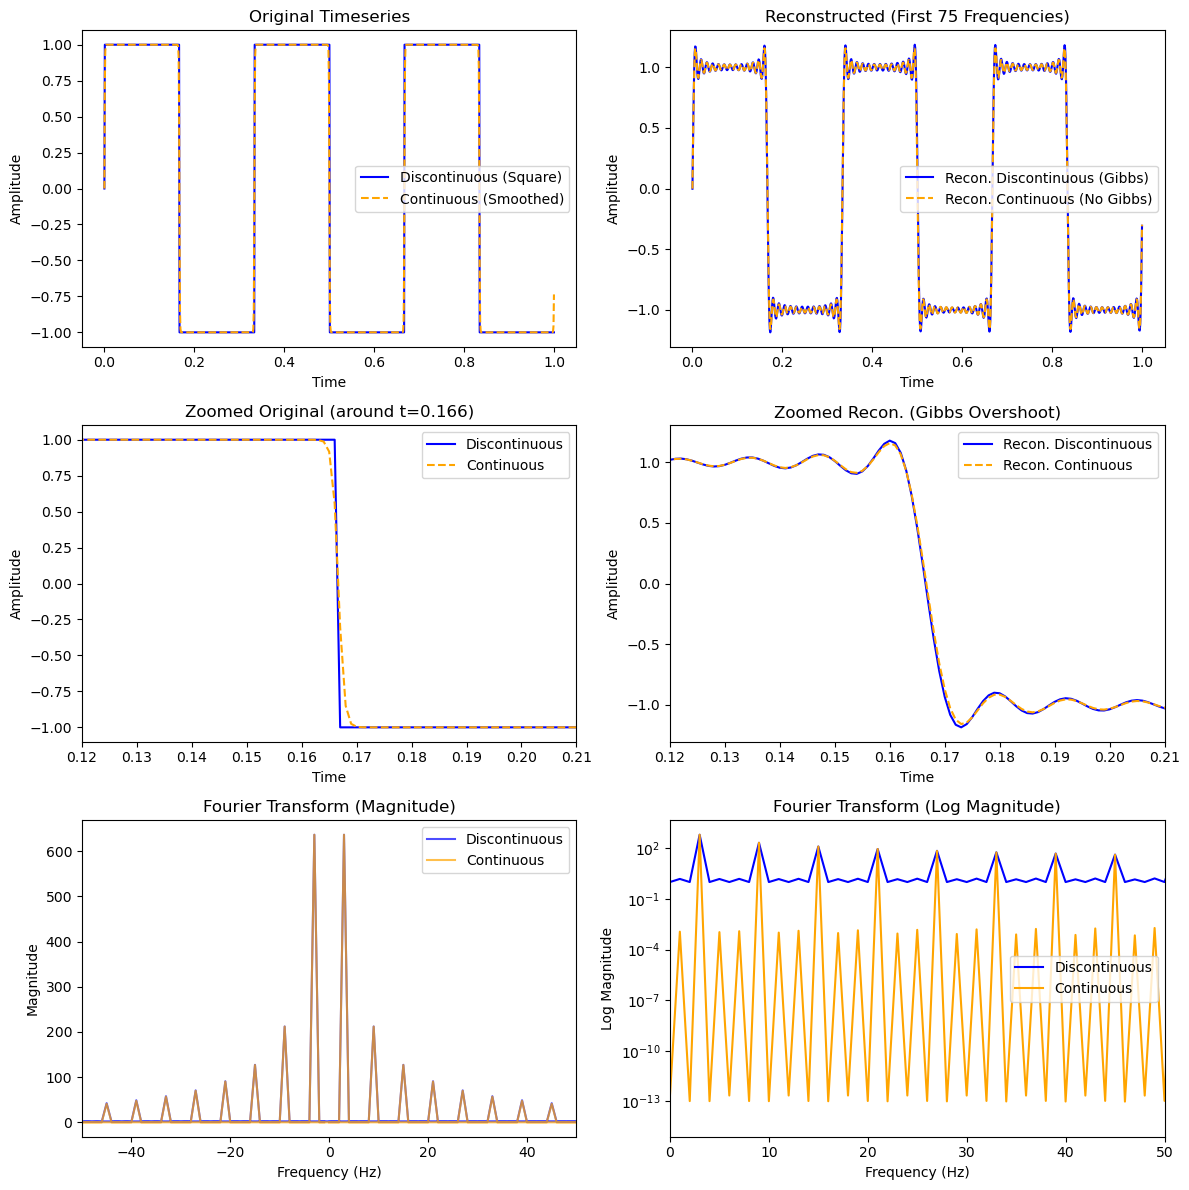

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Time array
t = np.linspace(0, 1, 1000, endpoint=False)

# Discontinuous timeseries (Square wave)
y_disc = np.sign(np.sin(2 * np.pi * 3 * t))

# Continuous timeseries (Smoothed square wave or Triangle wave)
# Let's use a smoothed version of the square wave, simulating a continuous transition
def smoothed_square(t, freq, steepness=50):
    return np.tanh(steepness * np.sin(2 * np.pi * freq * t))

y_cont = smoothed_square(t, 3)

# Fourier Transform
Y_disc = np.fft.fft(y_disc)
Y_cont = np.fft.fft(y_cont)
freqs = np.fft.fftfreq(len(t), d=t[1]-t[0])

# To illustrate Gibbs phenomenon, we truncate the Fourier series (keep only lower frequencies)
N_keep = 75 # Keep harmonics up to N_keep
mask = np.abs(freqs) <= N_keep
Y_disc_trunc = Y_disc * mask
Y_cont_trunc = Y_cont * mask

y_disc_recon = np.fft.ifft(Y_disc_trunc).real
y_cont_recon = np.fft.ifft(Y_cont_trunc).real

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Plot 1: Original Timeseries
axes[0, 0].plot(t, y_disc, label='Discontinuous (Square)', color='blue')
axes[0, 0].plot(t, y_cont, label='Continuous (Smoothed)', color='orange', linestyle='--')
axes[0, 0].set_title('Original Timeseries')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].legend()

# Plot 2: Reconstructed Timeseries (Gibbs Phenomenon)
axes[0, 1].plot(t, y_disc_recon, label='Recon. Discontinuous (Gibbs)', color='blue')
axes[0, 1].plot(t, y_cont_recon, label='Recon. Continuous (No Gibbs)', color='orange', linestyle='--')
axes[0, 1].set_title(f'Reconstructed (First {N_keep} Frequencies)')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend()

# NEW Plot 3: Zoomed-in Original Timeseries
axes[1, 0].plot(t, y_disc, label='Discontinuous', color='blue')
axes[1, 0].plot(t, y_cont, label='Continuous', color='orange', linestyle='--')
axes[1, 0].set_title('Zoomed Original (around t=0.166)')
axes[1, 0].set_xlim(0.12, 0.21)
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].legend()

# NEW Plot 4: Zoomed-in Reconstructed Timeseries (Gibbs)
axes[1, 1].plot(t, y_disc_recon, label='Recon. Discontinuous', color='blue')
axes[1, 1].plot(t, y_cont_recon, label='Recon. Continuous', color='orange', linestyle='--')
axes[1, 1].set_title('Zoomed Recon. (Gibbs Overshoot)')
axes[1, 1].set_xlim(0.12, 0.21)
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].legend()

# Plot 5: Fourier Transform (Magnitude)
axes[2, 0].plot(freqs, np.abs(Y_disc), label='Discontinuous', color='blue', alpha=0.7)
axes[2, 0].plot(freqs, np.abs(Y_cont), label='Continuous', color='orange', alpha=0.7)
axes[2, 0].set_title('Fourier Transform (Magnitude)')
axes[2, 0].set_xlabel('Frequency (Hz)')
axes[2, 0].set_ylabel('Magnitude')
axes[2, 0].set_xlim(-50, 50)
axes[2, 0].legend()

# Plot 6: Fourier Transform (Log scale to show slow vs fast decay)
axes[2, 1].semilogy(freqs[freqs >= 0], np.abs(Y_disc[freqs >= 0]), label='Discontinuous', color='blue')
axes[2, 1].semilogy(freqs[freqs >= 0], np.abs(Y_cont[freqs >= 0]), label='Continuous', color='orange')
axes[2, 1].set_title('Fourier Transform (Log Magnitude)')
axes[2, 1].set_xlabel('Frequency (Hz)')
axes[2, 1].set_ylabel('Log Magnitude')
axes[2, 1].set_xlim(0, 50)
axes[2, 1].legend()

plt.tight_layout()
plt.savefig('gibbs_plot.png')
print("Plot saved to gibbs_plot.png")


### 6.2 Data Conditioning: Windowing

To mitigate Gibbs ringing and spectral leakage in finite time-series, we use Data Conditioning by applying smoother windowing functions instead of rectangular ones.

Instead of abruptly cutting off data (rectangular window), we taper the ends to zero. Commonly used window functions for a discrete sequence of length $N$ include:

- **Rectangular Window**: $w[n] = 1$ (for $0 \le n \le N-1$)
- **Hann Window**: $w[n] = 0.5 - 0.5 \cos\left(\frac{2\pi n}{N-1}\right)$
- **Hamming Window**: $w[n] = 0.54 - 0.46 \cos\left(\frac{2\pi n}{N-1}\right)$
- **Flat-top Window**: $w[n] = 0.215 - 0.416 \cos\left(\frac{2\pi n}{N-1}\right) + 0.277 \cos\left(\frac{4\pi n}{N-1}\right) - 0.083 \cos\left(\frac{6\pi n}{N-1}\right) + 0.007 \cos\left(\frac{8\pi n}{N-1}\right)$

**When to use**:
- **Rectangular**: Only when the signal perfectly fits an integer number of cycles within your time window (rarely true for empirical data).

- **Hann/Hamming**: General purpose analysis. Smoothly tapers ends, vastly reducing side-lobes in the frequency domain at the cost of slightly widening the main frequency lobe (slight loss of frequency resolution).

- **Flat-top**: When accurate amplitude measurement is crucial (e.g., calibration).

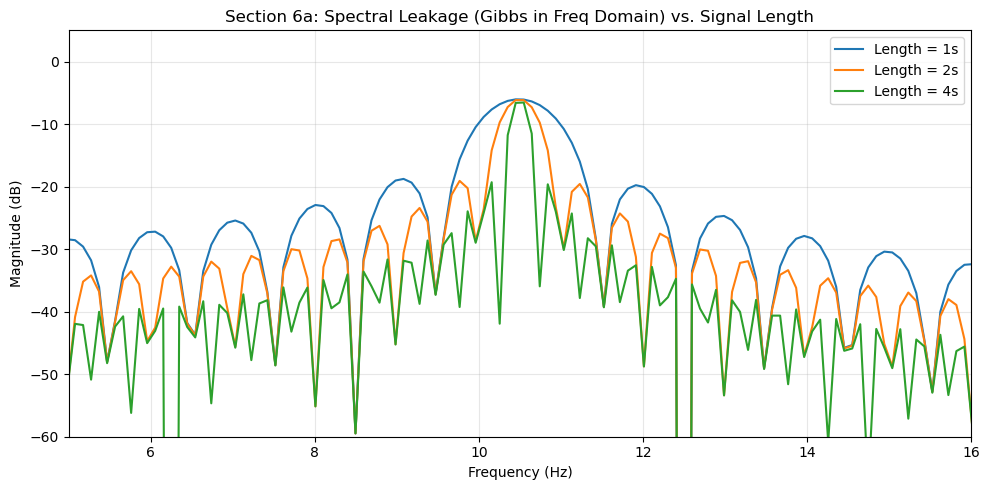

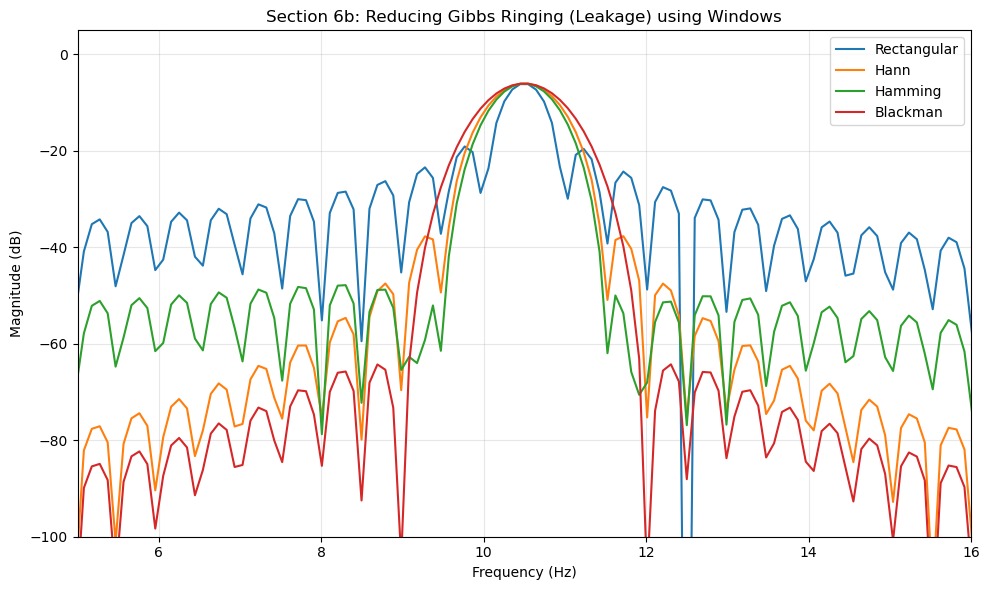

In [7]:
def section6_gibbs_and_windows():
    """
    Section 6: Gibbs phenomenon (spectral leakage) and Data Conditioning.
    Part A shows how signal length affects the leakage width.
    Part B shows how different window functions suppress the side lobes.
    """
    fs = 100
    f0 = 10.5 # Fractional frequency to guarantee leakage
    
    # --- Part A: Effect of signal length ---
    plt.figure(figsize=(10, 5))
    for T in [1, 2, 4]:
        t = np.arange(0, T, 1/fs)
        x = np.sin(2 * np.pi * f0 * t) # Pure rectangular truncation
        X = np.fft.fft(x, n=1024) # Zero-pad FFT for smooth curve visualization
        freqs = np.fft.fftfreq(1024, 1/fs)
        mask = freqs >= 0
        plt.plot(freqs[mask], 20 * np.log10(np.abs(X[mask]) / len(x)), label=f'Length = {T}s')
        
    plt.xlim(5, 16)
    plt.ylim(-60, 5)
    plt.title('Section 6a: Spectral Leakage (Gibbs in Freq Domain) vs. Signal Length')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Part B: Effect of Windowing ---
    T = 2
    t = np.arange(0, T, 1/fs)
    x = np.sin(2 * np.pi * f0 * t)
    
    windows = {
        'Rectangular': np.ones_like(x),
        'Hann': np.hanning(len(x)),
        'Hamming': np.hamming(len(x)),
        'Blackman': np.blackman(len(x))
    }
    
    plt.figure(figsize=(10, 6))
    for name, win in windows.items():
        xw = x * win
        Xw = np.fft.fft(xw, n=1024) # Zero-pad for smooth interpolation
        freqs = np.fft.fftfreq(1024, 1/fs)
        mask = freqs >= 0
        
        # Calculate power in dB, normalize by sum of window to keep amplitudes comparable
        magnitude = np.abs(Xw[mask]) / np.sum(win)
        plt.plot(freqs[mask], 20 * np.log10(np.maximum(magnitude, 1e-10)), label=name)

    plt.xlim(5, 16)
    plt.ylim(-100, 5)
    plt.title('Section 6b: Reducing Gibbs Ringing (Leakage) using Windows')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

section6_gibbs_and_windows()

## 7 Filtering Theory: Concepts, Design, and Implementation

In data analysis, we often want to isolate or remove specific frequency bands. From the **Convolution Theorem (Section 4)**, we know that if we want to apply a desired frequency response $H(\omega)$ to our signal's spectrum $X(\omega)$, we simply multiply them: $Y(\omega) = H(\omega)X(\omega)$. Equivalently, in the time domain, we convolve our continuous signal $x(t)$ with the filter's continuous impulse response $h(t)$ (which is defined as the exact output produced by the filter when it is subjected to an infinitely brief, instantaneous input pulse, known mathematically as the Dirac delta function $\delta(t)$): $y(t) = (x * h)(t)$.

But before we dive into the mathematics of implementation, we must understand why we filter and the physical realities of data collection.

### 7.1 Motivation: Why do we filter?

Filtering is the operation of rejecting undesired signal features while maintaining desired ones. In practice:

- **System Inertia**: Physical systems (like mechanical masses or thermal processes) possess inertia and naturally respond only to low-frequency inputs. Because high-frequency variations are physically unachievable by the system, filtering them out allows us to isolate and study the true, slow-moving physical dynamics without high-frequency distractions.

- **Control Effort & Damage**: Rapid switching from high-frequency noise has little effect on the actual state of a physical system, but if this noise is fed back into actuators or controllers, it can cause excessive heat, structural deformation, and damage. Filtering the feedback signal prevents actuators from fruitlessly attempting to track high-frequency noise (chatter), thereby saving energy and protecting hardware from wear and tear.

- **Sensor Noise**: Almost all empirical sensors are corrupted by white noise—a sequence of uncorrelated random variables with a flat spectrum containing power across all frequencies. Since the true signal is mostly low-frequency (due to inertia) and the white noise is spread everywhere, applying a low-pass filter eliminates the high-frequency noise bands, drastically improving the Signal-to-Noise Ratio (SNR) while preserving the actual data.

By applying filters, we can smooth signals, reduce required control efforts, and extract meaningful low-frequency dynamics buried in white noise.

Depending on the goal, filters are categorized by their ideal magnitude responses:

1. **Low-Pass**: Passes low frequencies and attenuates high frequencies.

1. **High-Pass**: Passes high frequencies and attenuates low frequencies.

1. **Band-Pass**: Passes a specific frequency band (can be built by cascading a low-pass and high-pass).

1. **Band-Stop**: Attenuates a specific frequency band (can be built by running a low-pass and high-pass in parallel).



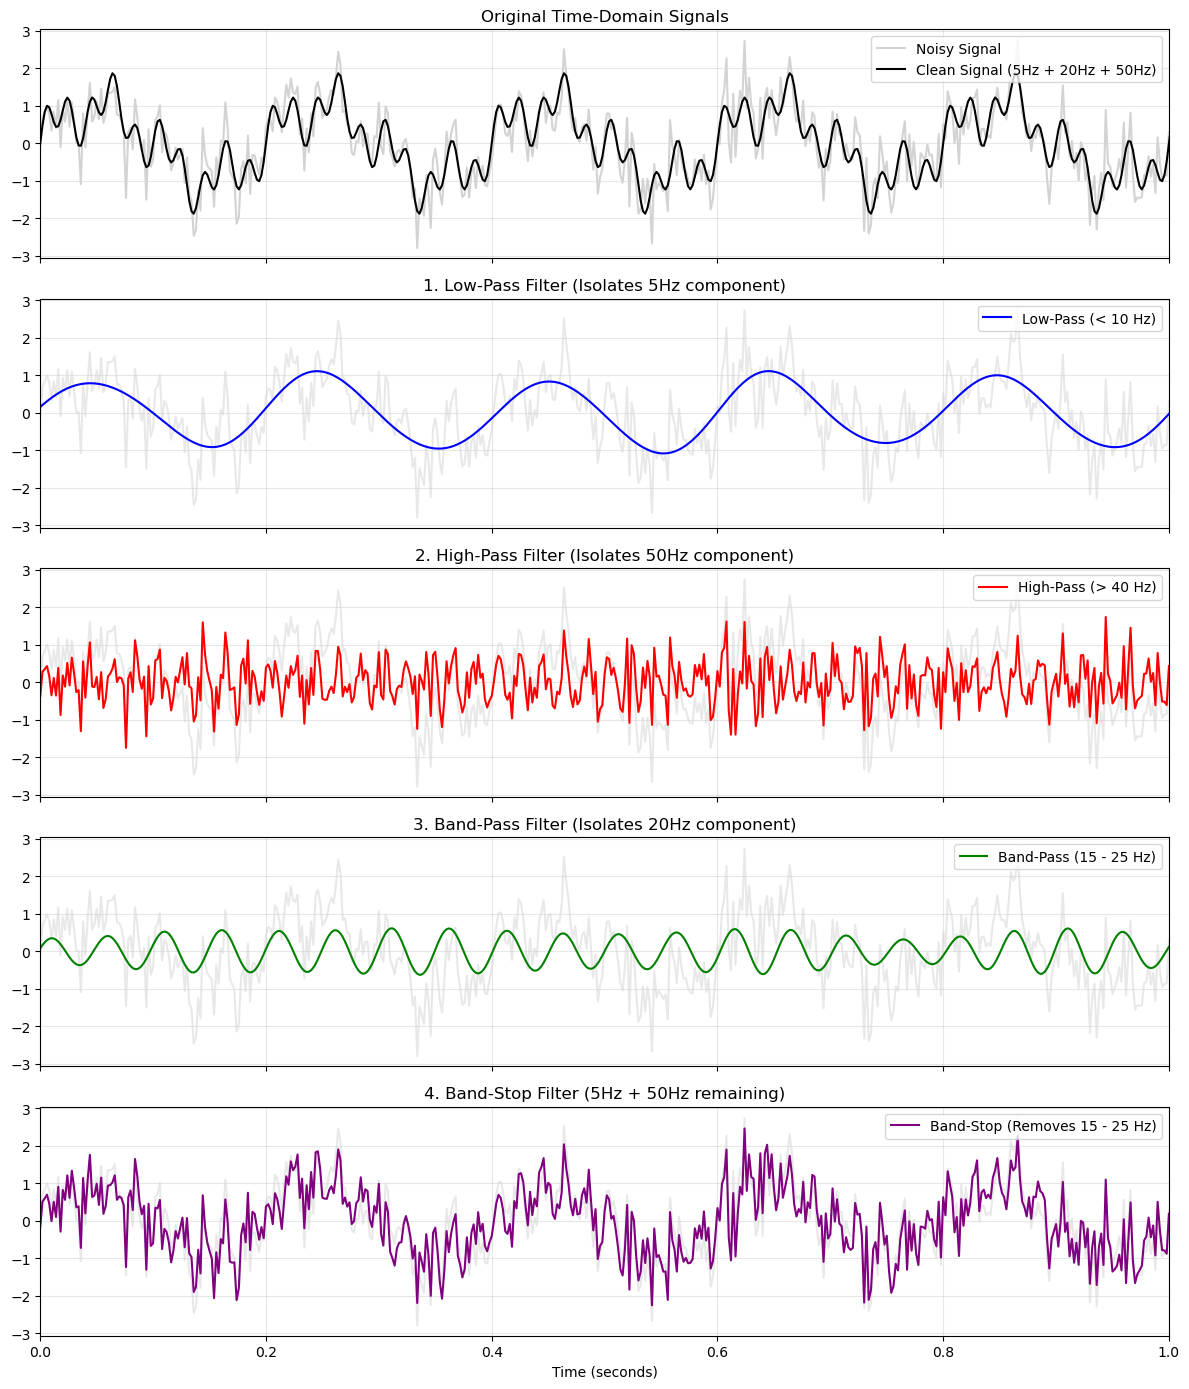

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic_signal(t):
    """
    Creates a synthetic signal containing three distinct frequency components:
    - Low frequency: 5 Hz
    - Mid frequency: 20 Hz
    - High frequency: 50 Hz
    Plus added Gaussian white noise.
    """
    f_low = 5.0
    f_mid = 20.0
    f_high = 50.0
    
    # Create the clean composite signal
    clean_signal = (
        1.0 * np.sin(2 * np.pi * f_low * t) + 
        0.5 * np.sin(2 * np.pi * f_mid * t) + 
        0.5 * np.sin(2 * np.pi * f_high * t)
    )
    
    # Add random white noise
    noise = np.random.normal(0, 0.5, len(t))
    noisy_signal = clean_signal + noise
    
    return clean_signal, noisy_signal

def apply_fourier_filter(signal, freqs, mask):
    """
    Applies a frequency domain mask to a signal and returns 
    the reconstructed time-domain signal.
    """
    # 1. Transform to Fourier domain
    F_signal = np.fft.fft(signal)
    
    # 2. Apply the mask (filtering)
    F_filtered = F_signal * mask
    
    # 3. Transform back to Time domain
    filtered_signal = np.fft.ifft(F_filtered)
    
    return np.real(filtered_signal)

def illustrate_filters():
    # Setup time axis
    fs = 500  # Sampling frequency in Hz
    t = np.arange(0, 2.0, 1/fs)  # 2 seconds of data
    
    clean_signal, noisy_signal = generate_synthetic_signal(t)
    
    # Compute the frequency bins for our signal
    freqs = np.fft.fftfreq(len(t), 1/fs)
    
    # --- Define Ideal Filter Masks in the Frequency Domain ---
    # 1. Low-Pass Filter: Keep frequencies <= 10 Hz
    low_pass_mask = np.abs(freqs) <= 10.0
    
    # 2. High-Pass Filter: Keep frequencies >= 40 Hz
    high_pass_mask = np.abs(freqs) >= 40.0
    
    # 3. Band-Pass Filter: Keep frequencies between 15 Hz and 25 Hz
    band_pass_mask = (np.abs(freqs) >= 15.0) & (np.abs(freqs) <= 25.0)
    
    # 4. Band-Stop Filter: Remove frequencies between 15 Hz and 25 Hz
    band_stop_mask = ~band_pass_mask
    
    # --- Apply Filters ---
    lp_signal = apply_fourier_filter(noisy_signal, freqs, low_pass_mask)
    hp_signal = apply_fourier_filter(noisy_signal, freqs, high_pass_mask)
    bp_signal = apply_fourier_filter(noisy_signal, freqs, band_pass_mask)
    bs_signal = apply_fourier_filter(noisy_signal, freqs, band_stop_mask)
    
    # --- Visualization ---
    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
    
    # Plot 1: Original Signals
    axes[0].plot(t, noisy_signal, color='lightgray', label='Noisy Signal')
    axes[0].plot(t, clean_signal, color='black', label='Clean Signal (5Hz + 20Hz + 50Hz)')
    axes[0].set_title('Original Time-Domain Signals')
    axes[0].legend(loc='upper right')
    
    # Plot 2: Low-Pass Filtered (Should mostly isolate the 5Hz wave)
    axes[1].plot(t, noisy_signal, color='lightgray', alpha=0.5)
    axes[1].plot(t, lp_signal, color='blue', label='Low-Pass (< 10 Hz)')
    axes[1].set_title('1. Low-Pass Filter (Isolates 5Hz component)')
    axes[1].legend(loc='upper right')
    
    # Plot 3: High-Pass Filtered (Should mostly isolate the 50Hz wave)
    axes[2].plot(t, noisy_signal, color='lightgray', alpha=0.5)
    axes[2].plot(t, hp_signal, color='red', label='High-Pass (> 40 Hz)')
    axes[2].set_title('2. High-Pass Filter (Isolates 50Hz component)')
    axes[2].legend(loc='upper right')
    
    # Plot 4: Band-Pass Filtered (Should isolate the 20Hz wave)
    axes[3].plot(t, noisy_signal, color='lightgray', alpha=0.5)
    axes[3].plot(t, bp_signal, color='green', label='Band-Pass (15 - 25 Hz)')
    axes[3].set_title('3. Band-Pass Filter (Isolates 20Hz component)')
    axes[3].legend(loc='upper right')
    
    # Plot 5: Band-Stop Filtered (Should contain 5Hz + 50Hz, missing 20Hz)
    axes[4].plot(t, noisy_signal, color='lightgray', alpha=0.5)
    axes[4].plot(t, bs_signal, color='purple', label='Band-Stop (Removes 15 - 25 Hz)')
    axes[4].set_title('4. Band-Stop Filter (5Hz + 50Hz remaining)')
    axes[4].legend(loc='upper right')
    axes[4].set_xlabel('Time (seconds)')
    
    for ax in axes:
        ax.set_xlim(0, 1) # Show only the first second for clearer wave viewing
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    illustrate_filters()

### 7.2 The Analog Prerequisite: Anti-Aliasing

Before we can apply digital filtering to a signal, we must sample the continuous-time signal $x(t)$. However, sampling introduces a profound vulnerability: **Aliasing**.

If a signal contains noise or dynamics at frequencies higher than the Nyquist frequency ($\pi/T_s$ or $f_s / 2$), those high frequencies will "fold" back into the low-frequency band during sampling, irrevocably corrupting the discrete signal.

To prevent this, an **anti-aliasing filter** must be applied before the signal is digitized. This is purely an analog, continuous-time filter (such as a simple resistor-capacitor (RC) circuit). For an RC circuit, the transfer function is $H(s) = \frac{\omega_c}{s + \omega_c}$, creating a first-order low-pass filter with a cutoff frequency $\omega_c = 1/RC$. At this cutoff frequency, the signal's power is reduced by half ($\approx -3$ dB).

      R
Vin o--\/\\\/\\\/\\--+--o Vout

               |
             ----- C
             -----
               |
GND o----------+--o GND


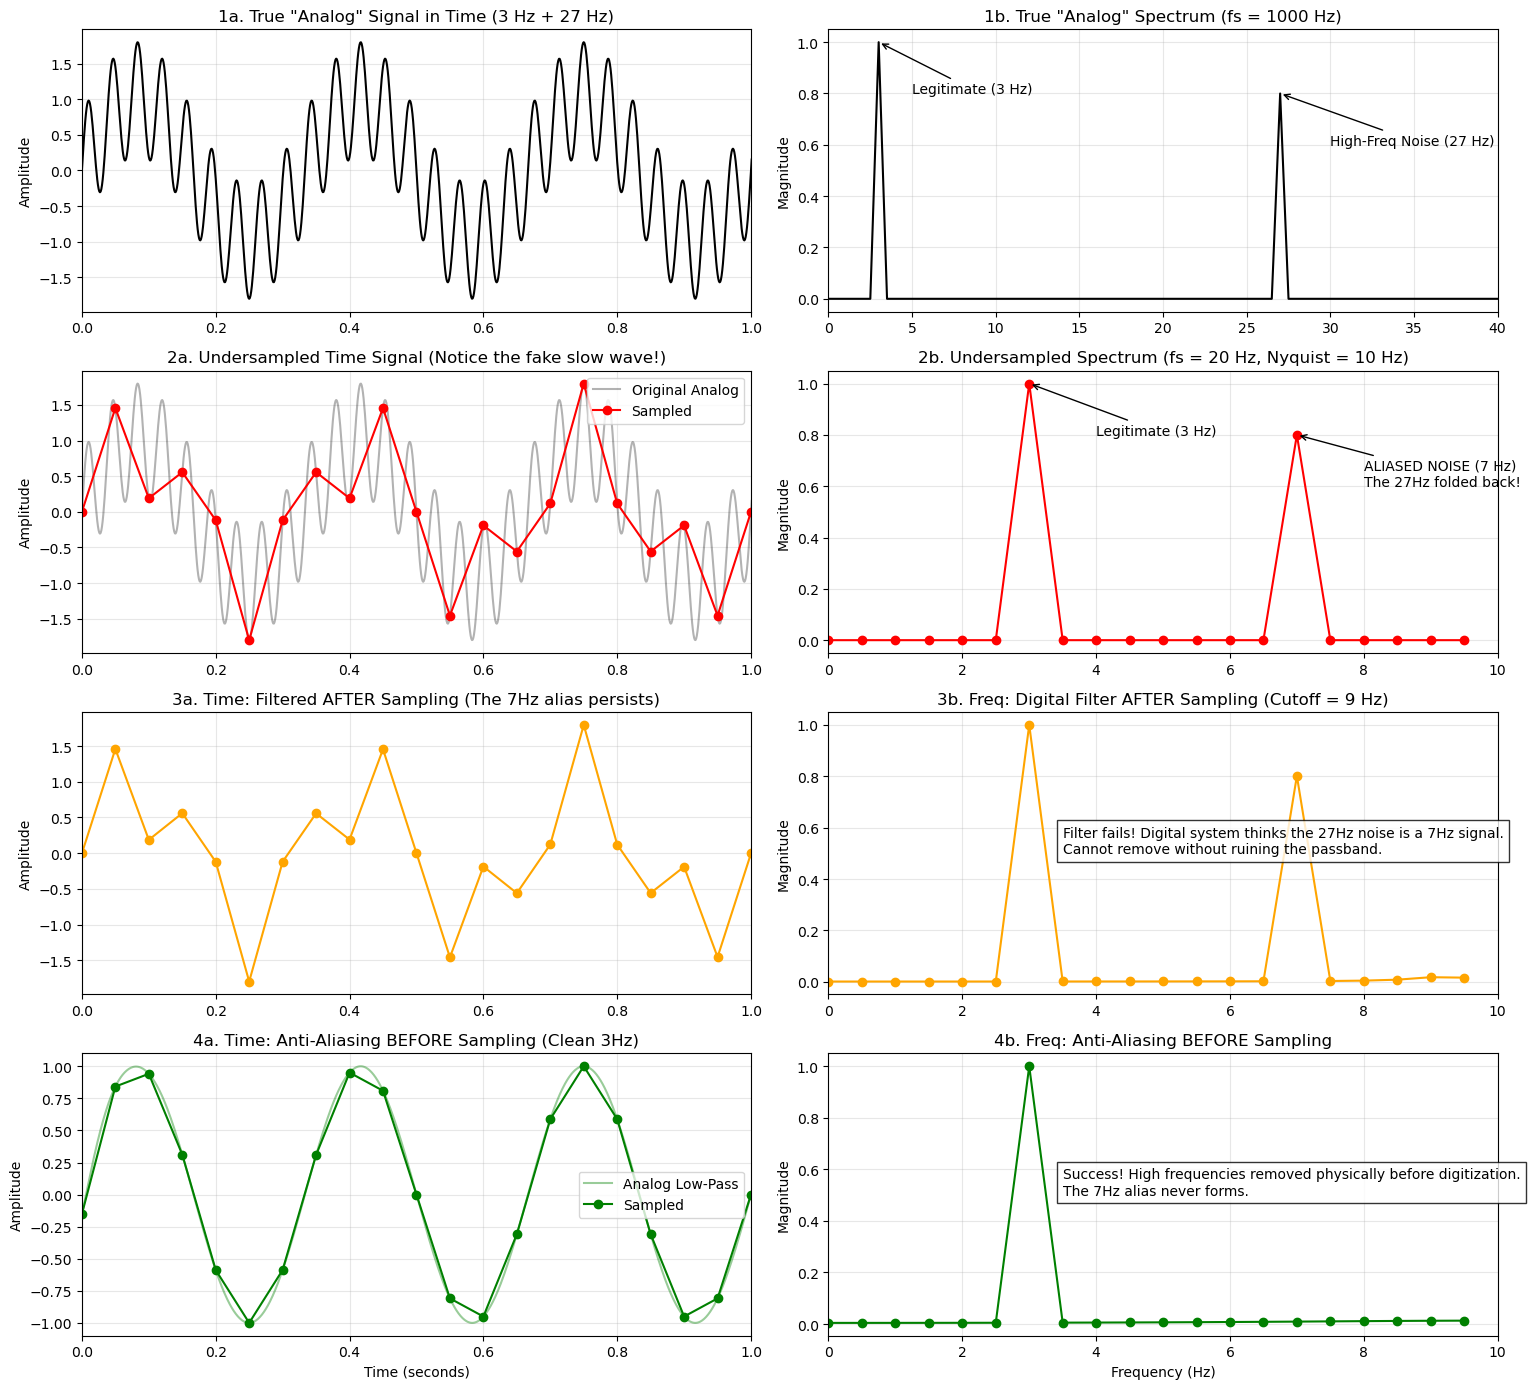

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def get_fft_spectrum(signal, fs):
    """Helper function to compute the single-sided amplitude spectrum."""
    X = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    mask = freqs >= 0
    # Normalize amplitude
    amplitude = 2.0 * np.abs(X[mask]) / len(signal)
    return freqs[mask], amplitude

def demonstrate_aliasing():
    # 1. Define our time domains
    # We use a very high sample rate (1000 Hz) to simulate the "continuous" analog real world
    fs_analog = 1000
    t_analog = np.arange(0, 2.0, 1/fs_analog)
    
    # We will sample our digital signal at 20 Hz (Nyquist frequency = 10 Hz)
    fs_digital = 20
    t_digital = np.arange(0, 2.0, 1/fs_digital)
    step = fs_analog // fs_digital
    
    # 2. Create the "Analog" Signal
    # Contains a legitimate low-frequency signal (3 Hz) and high-frequency noise (27 Hz)
    f_legit = 3.0
    f_noise = 27.0
    
    # Physical continuous signal
    x_analog = np.sin(2 * np.pi * f_legit * t_analog) + 0.8 * np.sin(2 * np.pi * f_noise * t_analog)
    
    # --- SCENARIO A: Bad Sampling (No Anti-Aliasing) ---
    # We sample the signal directly at 20 Hz.
    # Because 27 Hz > Nyquist (10 Hz), it will alias to: |27 - 20| = 7 Hz.
    x_bad_sampled = x_analog[::step]
    
    # Attempting to fix the bad sampling DIGITALLY AFTER the fact
    # We apply a digital low-pass filter at 9 Hz to remove "high frequencies"
    b_dig, a_dig = butter(4, 9.0, btype='low', fs=fs_digital)
    x_digital_filtered = filtfilt(b_dig, a_dig, x_bad_sampled)
    
    # --- SCENARIO B: Good Sampling (Anti-Aliasing applied BEFORE sampling) ---
    # We apply an analog low-pass filter (cutoff 10 Hz) to the continuous signal
    b_ana, a_ana = butter(4, 10.0, btype='low', fs=fs_analog)
    x_analog_filtered = filtfilt(b_ana, a_ana, x_analog)
    
    # Now we sample the clean, band-limited analog signal
    x_good_sampled = x_analog_filtered[::step]
    
    # --- Compute Fourier Transforms for Visualization ---
    f_ana, X_ana = get_fft_spectrum(x_analog, fs_analog)
    f_bad, X_bad = get_fft_spectrum(x_bad_sampled, fs_digital)
    f_dig_filt, X_dig_filt = get_fft_spectrum(x_digital_filtered, fs_digital)
    f_good, X_good = get_fft_spectrum(x_good_sampled, fs_digital)
    
    # --- Plotting the Results ---
    fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=False)
    
    # Plot 1: True Analog (Time & Freq)
    axes[0, 0].plot(t_analog, x_analog, color='black')
    axes[0, 0].set_title('1a. True "Analog" Signal in Time (3 Hz + 27 Hz)')
    axes[0, 0].set_xlim(0, 1.0) # Zoom in to 1 second
    axes[0, 0].set_ylabel('Amplitude')

    axes[0, 1].plot(f_ana, X_ana, color='black')
    axes[0, 1].set_title('1b. True "Analog" Spectrum (fs = 1000 Hz)')
    axes[0, 1].annotate('Legitimate (3 Hz)', xy=(3, 1), xytext=(5, 0.8), arrowprops=dict(facecolor='black', arrowstyle='->'))
    axes[0, 1].annotate('High-Freq Noise (27 Hz)', xy=(27, 0.8), xytext=(30, 0.6), arrowprops=dict(facecolor='red', arrowstyle='->'))
    axes[0, 1].set_xlim(0, 40)
    axes[0, 1].set_ylabel('Magnitude')
    
    # Plot 2: Undersampled (Time & Freq)
    axes[1, 0].plot(t_analog, x_analog, color='black', alpha=0.3, label='Original Analog')
    axes[1, 0].plot(t_digital, x_bad_sampled, color='red', marker='o', linestyle='-', label='Sampled')
    axes[1, 0].set_title('2a. Undersampled Time Signal (Notice the fake slow wave!)')
    axes[1, 0].set_xlim(0, 1.0)
    axes[1, 0].set_ylabel('Amplitude')
    axes[1, 0].legend()

    axes[1, 1].plot(f_bad, X_bad, color='red', marker='o')
    axes[1, 1].set_title('2b. Undersampled Spectrum (fs = 20 Hz, Nyquist = 10 Hz)')
    axes[1, 1].annotate('Legitimate (3 Hz)', xy=(3, 1), xytext=(4, 0.8), arrowprops=dict(facecolor='black', arrowstyle='->'))
    axes[1, 1].annotate('ALIASED NOISE (7 Hz)\nThe 27Hz folded back!', xy=(7, 0.8), xytext=(8, 0.6), arrowprops=dict(facecolor='red', arrowstyle='->'))
    axes[1, 1].set_xlim(0, 10)
    axes[1, 1].set_ylabel('Magnitude')
    
    # Plot 3: Filtered AFTER sampling (Time & Freq)
    axes[2, 0].plot(t_digital, x_digital_filtered, color='orange', marker='o', linestyle='-')
    axes[2, 0].set_title('3a. Time: Filtered AFTER Sampling (The 7Hz alias persists)')
    axes[2, 0].set_xlim(0, 1.0)
    axes[2, 0].set_ylabel('Amplitude')

    axes[2, 1].plot(f_dig_filt, X_dig_filt, color='orange', marker='o')
    axes[2, 1].set_title('3b. Freq: Digital Filter AFTER Sampling (Cutoff = 9 Hz)')
    axes[2, 1].text(0.35, 0.5, 'Filter fails! Digital system thinks the 27Hz noise is a 7Hz signal.\nCannot remove without ruining the passband.', 
                 fontsize=10, bbox=dict(facecolor='white', alpha=0.8), transform=axes[2, 1].transAxes)
    axes[2, 1].set_xlim(0, 10)
    axes[2, 1].set_ylabel('Magnitude')
    
    # Plot 4: Filtered BEFORE sampling (Time & Freq)
    axes[3, 0].plot(t_analog, x_analog_filtered, color='green', alpha=0.4, label='Analog Low-Pass')
    axes[3, 0].plot(t_digital, x_good_sampled, color='green', marker='o', linestyle='-', label='Sampled')
    axes[3, 0].set_title('4a. Time: Anti-Aliasing BEFORE Sampling (Clean 3Hz)')
    axes[3, 0].set_xlim(0, 1.0)
    axes[3, 0].set_xlabel('Time (seconds)')
    axes[3, 0].set_ylabel('Amplitude')
    axes[3, 0].legend()

    axes[3, 1].plot(f_good, X_good, color='green', marker='o')
    axes[3, 1].set_title('4b. Freq: Anti-Aliasing BEFORE Sampling')
    axes[3, 1].text(0.35, 0.5, 'Success! High frequencies removed physically before digitization.\nThe 7Hz alias never forms.', 
                 fontsize=10, bbox=dict(facecolor='white', alpha=0.8), transform=axes[3, 1].transAxes)
    axes[3, 1].set_xlim(0, 10)
    axes[3, 1].set_xlabel('Frequency (Hz)')
    axes[3, 1].set_ylabel('Magnitude')
    
    for row in axes:
        for ax in row:
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    demonstrate_aliasing()

### 7.3 Digital LTI Filters: The Difference Equation

Once the signal is safely sampled and anti-aliased, we process it using digital Linear Time-Invariant (LTI) filters. 

In the physical, continuous-time world, LTI systems (like the RC circuit we used for anti-aliasing) are governed by Linear Constant-Coefficient Differential Equations (e.g., equations involving $\frac{dy}{dt}$, $\frac{d^2x}{dt^2}$). When we move to the discrete, digital domain inside a computer, we don't have continuous derivatives. Instead, we approximate these derivatives using finite differences (e.g., $\frac{dy}{dt} \approx \frac{y[n] - y[n-1]}{T_s}$).

By algebraically substituting these discrete time-step differences into the continuous differential equation, we convert the physical model into a discrete sequence map. Thus, a digital filter is described by a constant-coefficient **Difference Equation**:

$$\sum_{k=0}^N a_k y[n-k] = \sum_{m=0}^M b_m x[n-m]$$

Explicitly defining our symbols:

- $n$: The current discrete time step (integer index).

- $x[n], y[n]$: The input data and output filtered sequences.

- $x[n-m], y[n-k]$: Past values of the input and output (feedback) sequences, delayed by $m$ and $k$ steps.

- $M, N$: The feedforward and feedback orders of the filter.

- $b_m, a_k$: The feedforward and feedback coefficients ($a_0$ is usually normalized to 1).

To analyze how this difference equation behaves in the frequency domain, we apply the Discrete-Time Fourier Transform (DTFT) directly to both sides of the equation. By the time-shifting property of the Fourier transform, a delay of $m$ discrete time steps ($x[n-m]$) becomes a multiplication by $e^{-i\omega m}$ in the frequency domain. Rearranging the terms to find the ratio of the output spectrum $Y(\omega)$ to the input spectrum $X(\omega)$ gives us the filter's Frequency Response $H(\omega)$:

$$H(\omega) = \frac{Y(\omega)}{X(\omega)} = \frac{\sum_{m=0}^M b_m e^{-i\omega m}}{\sum_{k=0}^N a_k e^{-i\omega k}}$$



### 7.3 FIR (Finite Impulse Response) Filters

If we set all feedback coefficients $a_k = 0$ for $k \geq 1$, the filter relies exclusively on present and past inputs. The difference equation simplifies to a discrete convolution:

$$y[n] = \sum_{m=0}^M b_m x[n-m]$$

The discrete impulse response $h[n]$ is simply the sequence of feedforward coefficients $b_m$. **Because $M$ is finite, the impulse response has a finite length of $M+1$.**


**Construction via Window Design**:
To design an ideal low-pass filter (a perfect rectangle up to cutoff $\omega_c$), the Inverse Discrete-Time Fourier Transform yields a Sinc function: $h_{ideal}[n] = \frac{\sin(\omega_c n)}{\pi n}$.

Because $h_{ideal}[n]$ is infinitely long and non-causal, we truncate it to length $M$ and shift it. However, as proven in **Section 6.1**, abrupt truncation causes severe Gibbs ringing near the cutoff frequency. We solve this by applying **Data Conditioning (Section 6.2)**, multiplying the truncated impulse response by a smoothing window sequence $w[n]$ (like a Hamming window):

$$h_{FIR}[n] = h_{ideal}[n - M/2] \cdot w[n]$$

### 7.4 IIR (Infinite Impulse Response) Filters

If the feedback coefficients $a_k \neq 0$ for $k \geq 1$, the filter utilizes recursive feedback. To understand why this happens, imagine feeding a single, instantaneous spike (an impulse) into the filter. Because the filter computes its current output using its past outputs (the denominator in $H(\omega)$), that initial spike enters a continuous loop. It is multiplied by the feedback coefficients and cycled back into the calculation for the next time step, and the next. As a result, an initial impulse will continue to resonate infinitely, gradually decaying but mathematically never reaching absolute zero.

**While this recursive feedback allows IIR filters to achieve sharp cutoffs with very little computational effort, it comes with a major trade-off: phase distortion**. The feedback loop delays different frequency components by different amounts of time, which warps and distorts the physical time-domain shape of the signal.

Designing an IIR filter directly in the digital domain is notoriously difficult because balancing the infinite feedback loop to ensure stability is tricky. Instead, engineers use a clever shortcut. They start by designing a classical, continuous-time analog filter using mathematical models of physical components like resistors, capacitors, and inductors in the Laplace $s$-domain (e.g., $H(s) = \frac{\omega_c}{s + \omega_c}$).

*But why does a continuous analog filter naturally possess an Infinite Impulse Response?* Physical analog systems inherently process energy over time. If you strike an analog filter with an instantaneous impulse of energy, reactive components like capacitors absorb that energy and then discharge it exponentially. Mathematically, this continuous exponential decay never reaches absolute zero; it merely gets infinitely small. Thus, all physical, continuous-time analog filters are inherently IIR systems governed by differential equations.

Since analog filter design has been perfected over the last century (yielding optimized mathematical templates like Butterworth or Chebyshev filters), this analog modeling step is easy. Engineers take the analog transfer function $H(s)$ and use a mathematical conversion formula—most commonly the Bilinear Transform—to directly translate that continuous-time continuous-energy blueprint into the discrete digital coefficients ($a_k$ and $b_m$) needed for our difference equation. The continuous analog physical decay seamlessly becomes the discrete mathematical feedback loop ($a_k$), perfectly preserving the infinite impulse response in the digital computer.




### 7.4 Advanced Techniques: Non-Causal and Non-Linear Filtering

**Causal vs. Non-Causal (Zero-Phase) Filtering**:
A system is causal if the output depends only on present and past inputs. In real-time control systems, causal filters are strictly required. However, causal filters (especially IIR) introduce a phase shift—delaying different frequencies by different amounts, which visibly distorts the signal's shape.

In post-processing data analysis, we have the entire signal available, so we can use non-causal techniques to eliminate this distortion. We apply a causal filter $H(\omega)$ to the data, reverse the resulting sequence in time, and apply the filter again $H(-\omega)$.
The overall transfer function becomes $H(-\omega)H(\omega) = |H(\omega)|^2$.
This remarkably efficient trick squares the magnitude response (making the cutoff steeper) and entirely cancels out the phase shift, resulting in zero phase distortion. (This is implemented via filtfilt in environments like MATLAB/SciPy).

**Non-Linear Filtering for Outliers**:
While LTI filters are powerful for removing frequency bands, they fail against data outliers—isolated, massive spikes caused by measurement errors. If a massive outlier passes through an LTI filter, its energy smears across surrounding data points.
To handle outliers, we use non-linear filters such as the **Median filter**. Instead of a weighted sum, a median filter replaces $x[n]$ with the median value of its surrounding neighbors. It vastly outperforms a linear moving-average filter for outlier rejection while perfectly preserving sharp step-changes in the true signal.

### 7.5 FIR vs. IIR: When to use what?

- **Use FIR when**: You are analyzing data where the precise shape in the time domain must be preserved (e.g., medical ECG peaks, seismic wave arrivals). If you have sufficient computational power, FIR is preferred due to its linear phase and absolute mathematical stability.

- **Use IIR when**: You need an aggressively sharp cutoff, memory/computation is strictly limited (e.g., real-time embedded microcontrollers), or phase distortion is irrelevant to your analysis (e.g., purely listening to an audio stream, or calculating power spectrums).

- **Use Median Filters when**: Your data is plagued by isolated measurement errors or salt-and-pepper noise, rather than continuous-band white noise.

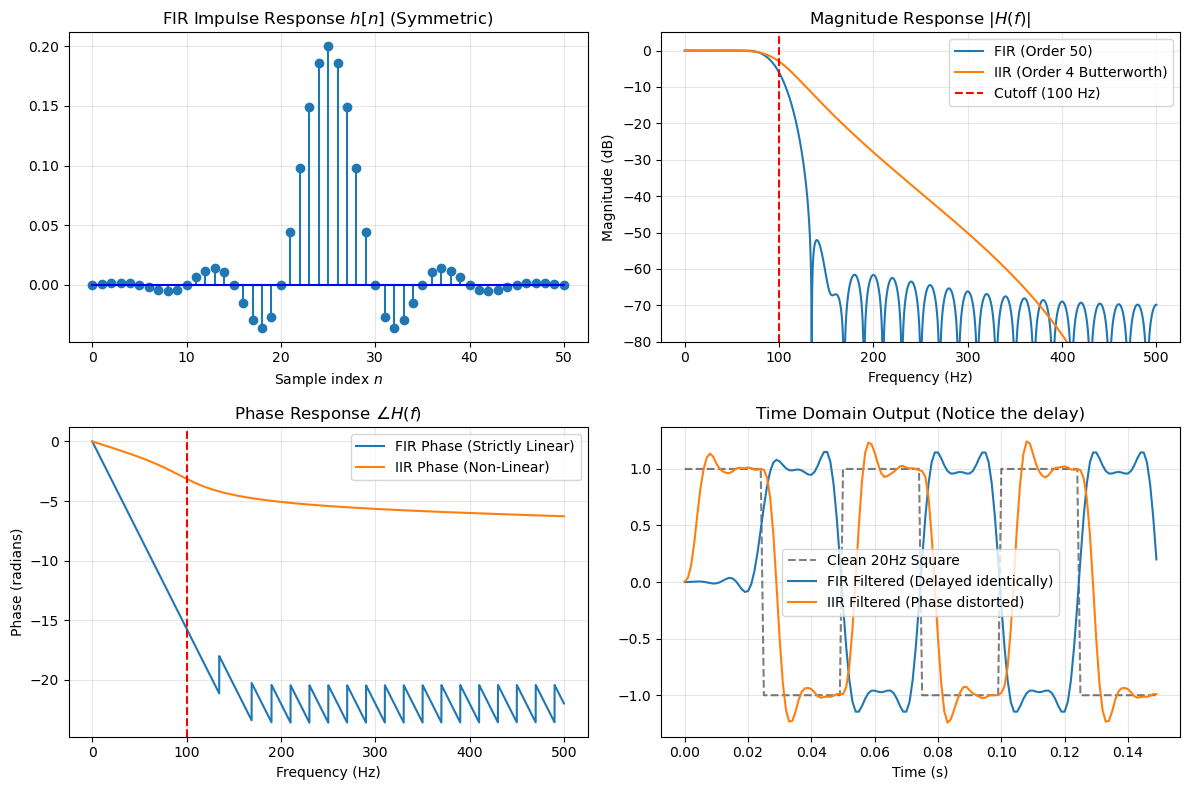

In [17]:
def section7_filtering():
    """
    Demonstrates FIR construction via windowing, IIR construction via analog 
    prototypes, and compares their phase and magnitude responses.
    """
    fs = 1000
    cutoff = 100  # 100 Hz low-pass cutoff
    
    # --- Part A: FIR Filter Construction via Window Design ---
    numtaps = 51  # Length of filter (M + 1)
    M = numtaps - 1
    n = np.arange(numtaps)
    
    # Angular cutoff frequency (normalized to sampling rate)
    w_c = 2 * np.pi * (cutoff / fs)
    
    # Create the ideal impulse response (sinc), shifted by M/2 to be causal
    shifted_n = n - M/2
    h_ideal = np.zeros(numtaps)
    
    center_idx = int(M/2)
    h_ideal[center_idx] = w_c / np.pi # Handle the division by zero limit
    
    mask = np.arange(numtaps) != center_idx
    h_ideal[mask] = np.sin(w_c * shifted_n[mask]) / (np.pi * shifted_n[mask])
            
    # Apply Data Conditioning: multiply by Hamming window to suppress Gibbs ringing
    window = np.hamming(numtaps)
    h_fir = h_ideal * window
    
    # --- Part B: IIR Filter Construction (Butterworth) ---
    # Construct a 4th order IIR filter
    # Returns the difference equation feedforward (b) and feedback (a) coefficients
    b_iir, a_iir = signal.butter(4, cutoff, btype='low', fs=fs)
    
    # --- Part C: Frequency and Phase Response Comparison ---
    # Compute frequency responses mapping directly to H(z) on the unit circle
    w_fir, h_fir_resp = signal.freqz(h_fir, 1, worN=8000, fs=fs)
    w_iir, h_iir_resp = signal.freqz(b_iir, a_iir, worN=8000, fs=fs)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Plot 1: FIR Impulse Response
    axes[0, 0].stem(n, h_fir, basefmt="b-")
    axes[0, 0].set_title('FIR Impulse Response $h[n]$ (Symmetric)')
    axes[0, 0].set_xlabel('Sample index $n$')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Magnitude Response
    axes[0, 1].plot(w_fir, 20 * np.log10(np.maximum(np.abs(h_fir_resp), 1e-10)), label=f'FIR (Order {M})')
    axes[0, 1].plot(w_iir, 20 * np.log10(np.maximum(np.abs(h_iir_resp), 1e-10)), label='IIR (Order 4 Butterworth)')
    axes[0, 1].axvline(cutoff, color='red', linestyle='--', label='Cutoff (100 Hz)')
    axes[0, 1].set_title('Magnitude Response $|H(f)|$')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('Magnitude (dB)')
    axes[0, 1].set_ylim(-80, 5)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Phase Response
    # Unwrap phase to show the strictly linear behavior of the FIR filter
    phase_fir = np.unwrap(np.angle(h_fir_resp))
    phase_iir = np.unwrap(np.angle(h_iir_resp))
    
    axes[1, 0].plot(w_fir, phase_fir, label='FIR Phase (Strictly Linear)')
    axes[1, 0].plot(w_iir, phase_iir, label='IIR Phase (Non-Linear)')
    axes[1, 0].axvline(cutoff, color='red', linestyle='--')
    axes[1, 0].set_title('Phase Response $\\angle H(f)$')
    axes[1, 0].set_xlabel('Frequency (Hz)')
    axes[1, 0].set_ylabel('Phase (radians)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Time-Domain Application (Difference Equations)
    # Test signal: A square wave composed of odd harmonics (e.g. 20, 60, 100 Hz...) 
    # + 250Hz high-frequency noise
    # A square wave clearly shows asymmetry and shape distortion if relative phases are changed
    t = np.arange(0, 0.15, 1/fs)
    x_clean = signal.square(2 * np.pi * 20 * t)
    x_noisy = x_clean + 0.6 * np.sin(2 * np.pi * 250 * t)
    
    # Apply difference equations using scipy's lfilter
    y_fir = signal.lfilter(h_fir, [1.0], x_noisy)
    y_iir = signal.lfilter(b_iir, a_iir, x_noisy)
    
    axes[1, 1].plot(t, x_clean, 'k--', alpha=0.5, label='Clean 20Hz Square')
    axes[1, 1].plot(t, y_fir, label='FIR Filtered (Delayed identically)')
    axes[1, 1].plot(t, y_iir, label='IIR Filtered (Phase distorted)')
    axes[1, 1].set_title('Time Domain Output (Notice the delay)')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

section7_filtering()

## 8. Summary & Best Practices in Data Analysis

To conclude this mathematical survey, let's summarize the typical pipeline for analyzing time-series data using Fourier methods:

1. **Anti-Aliasing**: Apply an analog low-pass filter to the physical signal before sampling to prevent high-frequency noise from corrupting the lower bands.

1. **Data Preparation (Conditioning)**: Remove the DC offset (subtract the mean) to prevent a massive spike at $\omega = 0$ which can obscure low frequencies. Filter out extreme outliers using a non-linear median filter.

1. **Windowing**: Multiply the finite data segment by a Hamming or Hann window to prevent Gibbs ringing and spectral leakage.

1. **Transformation**: Apply the Fast Fourier Transform (FFT).

1. **Spectral Analysis**: Calculate the Power Spectral Density (PSD) using $|X(\omega)|^2 / N$. For noisy data, use Welch's method (averaging the PSDs of overlapping windowed segments) to reduce variance.

1. **Filtering**: If unwanted noise bands are discovered via the PSD, design a digital filter. Use FIR (or zero-phase forward-backward IIR filtering) for phase-sensitive data; use causal IIR for aggressive, real-time filtering.

The mathematical rigor underlying these transforms ensures that while we manipulate and shift our perspective of the data, the fundamental information and energy of the system remain precisely conserved.